# Arbitrage with Put-Call Parity


## Data

Use the data in `data/option_data_bb_NVDA.xlsx`
* tab `spot`: the underlying NVDA quote
* one tab per expiration date (e.g. `2026-09-18`): the option chain for that expiration


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 14

TICK = "NVDA"
EXPRY = "2026-09-18"
ATM = 210
N_CONTRACTS = 1000
MULT = 100  # shares per option contract

_candidates = [
    Path("data/option_data_bb_NVDA.xlsx"),
    Path("../data/option_data_bb_NVDA.xlsx"),
    Path("/Users/christophermo/Desktop/FINM-Quizzes/data/option_data_bb_NVDA.xlsx"),
    Path("/Users/christophermo/Downloads/option_data_bb_NVDA.xlsx"),
]
FILEDATA = next(p for p in _candidates if p.exists())
print("Using:", FILEDATA.resolve())

spot = pd.read_excel(FILEDATA, sheet_name="spot")
spot = spot.rename(columns={"Unnamed: 0": "field"}).set_index("field")
S = float(spot.loc["price"].iloc[0])
print(f"Spot {TICK} = {S:.2f}")

opt = pd.read_excel(FILEDATA, sheet_name=EXPRY)
calls = opt[opt["option type"].str.lower() == "call"].set_index("strike price").sort_index()
puts = opt[opt["option type"].str.lower() == "put"].set_index("strike price").sort_index()
strikes = calls.index.intersection(puts.index).sort_index()
days = int(calls.loc[ATM, "days to expiration"])
print(f"Expiration {EXPRY} | days = {days} | n strikes = {len(strikes)}")

def pv(X, days, r):
    """ACT/360 present value: X / (1 + days/360 * r)"""
    return X / (1 + (days / 360.0) * r)

spot


Using: /Users/christophermo/Desktop/FINM-Quizzes/data/option_data_bb_NVDA.xlsx
Spot NVDA = 208.64
Expiration 2026-09-18 | days = 102 | n strikes = 31


,NVDA US Equity
field,
name,NVIDIA Corp
last update date,2026-06-08 00:00:00
last update time,20:56:12.393006
price,208.64
volume,138372837
hist vol 30d,46.005544
hist vol 60d,40.86636


#### A note on dividends

NVDA pays a small quarterly dividend. Bloomberg's `finance rate` is an *implied* financing rate backed out from option mids; for a dividend payer it reflects the **net** cost of carry (financing minus the dividend), so the put-call-parity check below already accounts for NVDA's dividend without a separate term.


***


# 1. Put-Call-Parity


Consider the option chain with expiration `2026-09-18`.

### 1.1.

For every listed strike, calculate how closely put-call parity holds. That is, compare the call spread $c-p$ to the present value moneyness, $S-K^*$.

Make a chart showing this error across strikes.

#### Note: Financing Rate

The financing rate is quoted from annual swaps with ACT/360 compounding:

$$PV(X) = \frac{X}{1+\frac{\text{days}}{360} r}$$

Parity error:

$$\text{error} = (c-p) - (S - K^*), \qquad K^* = PV(K)$$


In [2]:
rows = []
for K in strikes:
    c = float(calls.loc[K, "price"])
    p = float(puts.loc[K, "price"])
    r = float(calls.loc[K, "finance rate"])
    d = int(calls.loc[K, "days to expiration"])
    Kstar = pv(K, d, r)
    rows.append({
        "strike": K,
        "call": c,
        "put": p,
        "c-p": c - p,
        "S-K*": S - Kstar,
        "error": (c - p) - (S - Kstar),
        "finance rate": r,
    })

parity = pd.DataFrame(rows).set_index("strike")
parity[["call", "put", "c-p", "S-K*", "error"]].head(10)


,call,put,c-p,S-K*,error
strike,,,,,
130,82.05,1.03,81.02,80.0817,0.9383
135,76.52,1.23,75.29,75.1372,0.1528
140,71.15,1.49,69.66,70.1926,-0.5326
145,66.59,1.89,64.70,65.2481,-0.5481
150,62.20,2.22,59.98,60.3035,-0.3235
155,57.92,2.71,55.21,55.3592,-0.1492
160,54.15,3.44,50.71,50.4146,0.2954
165,49.21,4.15,45.06,45.4701,-0.4101
170,44.77,5.05,39.72,40.5256,-0.8056


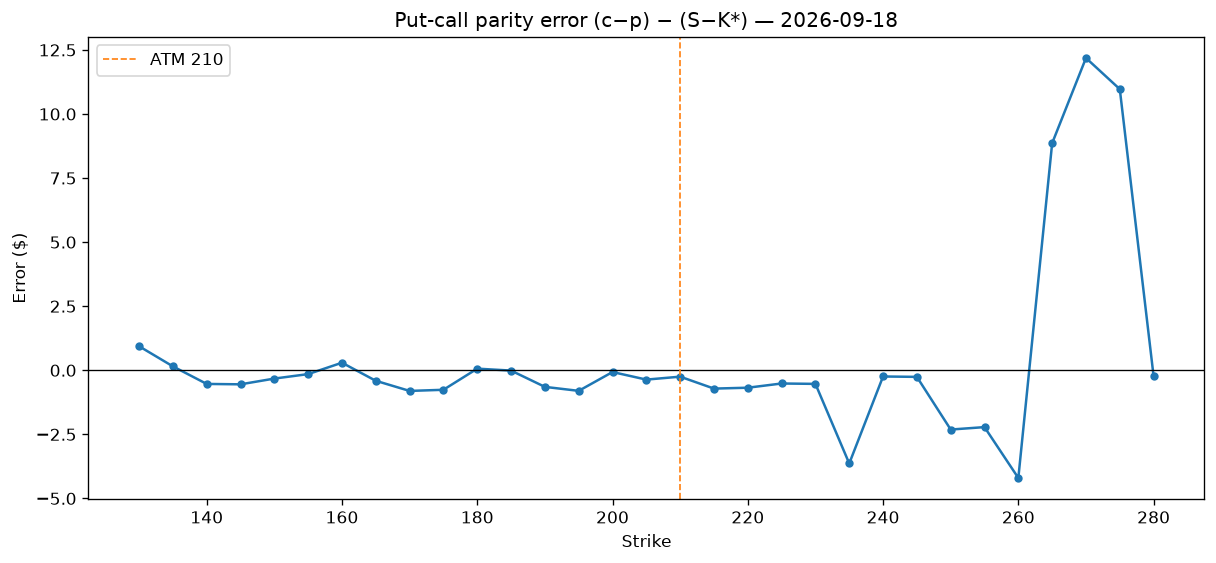

count    31.000000
mean      0.395092
std       3.604430
min      -4.203177
25%      -0.697406
50%      -0.363762
75%      -0.040055
max      12.185931

ATM 210 error = -0.2492


In [3]:
ax = parity["error"].plot(marker="o", ms=4, title=f"Put-call parity error (c−p) − (S−K*) — {EXPRY}")
plt.axhline(0, color="k", lw=0.8)
plt.axvline(ATM, color="C1", ls="--", label=f"ATM {ATM}")
plt.xlabel("Strike")
plt.ylabel("Error ($)")
plt.legend()
plt.show()

print(parity["error"].describe().to_string())
print(f"\nATM {ATM} error = {parity.loc[ATM, 'error']:.4f}")


**Answer / explanation (1.1):** Across strikes, the parity error is usually small (median about **-0.36**). Near ATM=210 the gap is only about **$-0.25** per share. Errors get larger in the wings (especially high strikes), where quotes are thinner and mids can be noisy.


### 1.2. Put-Call Arbitrage

Suppose you put on a trade
* sized to `1,000` long-short option contracts
* at the ATM strike `210`

(Each contract is `100` shares ⇒ `100,000` shares.)

Describe the position in calls, puts, shares, and cash.


In [4]:
c = float(parity.loc[ATM, "call"])
p = float(parity.loc[ATM, "put"])
r = float(parity.loc[ATM, "finance rate"])
Kstar = pv(ATM, days, r)
err = (c - p) - (S - Kstar)

print(f"S = {S:.4f}")
print(f"K = {ATM}, days = {days}, r = {r:.6%}")
print(f"K* = PV(K) = {Kstar:.4f}")
print(f"c − p = {c - p:.4f}")
print(f"S − K* = {S - Kstar:.4f}")
print(f"error = (c−p) − (S−K*) = {err:.4f}")

if err < 0:
    # synthetic forward cheap vs stock → buy synthetic, short stock? 
    # error < 0 means c-p < S-K* → conversion earns |error|
    print("\nDirection: CONVERSION (error < 0)")
    print("  short calls, long puts, long shares, finance/borrow PV(K)")
else:
    print("\nDirection: REVERSAL (error > 0)")
    print("  long calls, short puts, short shares, lend PV(K)")

pnl_share = abs(err)
pnl_pkg = pnl_share * N_CONTRACTS * MULT
print(f"\nExpected locked PnL ≈ ${pnl_share:.4f} per share")
print(f"On {N_CONTRACTS:,} contracts × {MULT} shares = ${pnl_pkg:,.2f}")


S = 208.6400
K = 210, days = 102, r = 3.958562%
K* = PV(K) = 207.6708
c − p = 0.7200
S − K* = 0.9692
error = (c−p) − (S−K*) = -0.2492

Direction: CONVERSION (error < 0)
  short calls, long puts, long shares, finance/borrow PV(K)

Expected locked PnL ≈ $0.2492 per share
On 1,000 contracts × 100 shares = $24,922.00


**Answer (1.2):** Because `error < 0` at the ATM (`c−p` is below `S−K*`), the **conversion** is the cheap→expensive trade:

| Leg | Position | Size |
|-----|----------|------|
| Call 210 | **Short** | 1,000 contracts |
| Put 210 | **Long** | 1,000 contracts |
| Shares | **Long** | 100,000 |
| Cash | **Borrow** PV(K)×100,000 ≈ **$20,767,078** (to be repaid as $K per share at expiry) |

This is synthetic short-forward + long stock, locked against the strike.


### 1.3.

What is the expected PnL of your trade? Detail what you expect to make in each leg.


**Answer (1.3):** Using mids, locked value per share is

$$
\underbrace{(S-K^*)}_{0.9692} - \underbrace{(c-p)}_{0.7200} = 0.2492.
$$

Scaled to the package:

$$
0.2492 \times 100{,}000 \approx \$24,922.00.
$$

**By leg (per share, conceptual):**
- Short call / long put: you *receive* $c$ and *pay* $p$ → net option cash $+0.7200$
- Long stock: pay $S = 208.64$
- Borrow $K^*$ now, repay $K$ at $T$: financing credit $+207.6708$ today

Net today ≈ **$+0.2492/share**; at expiry the call−put+stock package delivers $K$, which repays the loan → terminal residual ≈ 0. The edge is earned up front (mark-to-parity), not from a directional bet.


### 1.4.

Is this an arbitrage? What risks are there?

Specify whether you are trading a **conversion** or **reversal**.


**Answer (1.4):** This is a **conversion** (short call, long put, long stock).

It is *parity-style* arbitrage in the textbook sense if you can trade at these mids and hold to expiry with the quoted financing. In practice it is **not risk-free**:

- **Bid/ask & capacity:** you sell the call nearer the bid and buy the put nearer the ask; the ~$0.25 mid edge can vanish in spreads (1,000 contracts is large vs displayed sizes).
- **Pin / early exercise / borrow:** American features, hard-to-borrow stock, and dividend timing can disturb the lock.
- **Financing / model:** the Bloomberg `finance rate` is itself implied; if true funding differs, the edge changes (see 1.5).
- **Mark-to-market:** even if terminal payoff is locked, interim P&L can move.


### 1.5.

Suppose the ATM=210 trade is not an arbitrage, but an indication of the true financing rate.

Solve for a financing rate that sets ATM profits to 0 (ACT/360).


In [5]:
# Solve r_imp so error = 0 at ATM:
# c - p = S - K / (1 + days/360 * r)
# => r = (K / (S - (c-p)) - 1) * 360 / days
c = float(parity.loc[ATM, "call"])
p = float(parity.loc[ATM, "put"])
r_quoted = float(parity.loc[ATM, "finance rate"])
r_imp = (ATM / (S - (c - p)) - 1) * 360 / days

print(f"Quoted finance rate:   {r_quoted:.6%}")
print(f"Implied finance rate:  {r_imp:.6%}")
print(f"Difference:            {(r_imp - r_quoted)*1e4:.2f} bps")


Quoted finance rate:   3.958562%
Implied finance rate:  3.530770%
Difference:            -42.78 bps


**Answer (1.5):** The rate that forces ATM parity is about **3.5308%**, roughly **43 bps below** the quoted Bloomberg finance rate (3.9586%). So the ATM “edge” may just mean the market’s effective carry is a bit richer than the printed swap-implied rate.


### 1.6.

Consider the strike at `270`. What is your expected profit from that arbitrage?

Aside from the financing rate, point to specific data which concerns you about putting on this trade.


In [6]:
K = 270
row = parity.loc[K]
err = float(row["error"])
print(row[["call", "put", "c-p", "S-K*", "error"]].to_string())
print(f"\n|error| = ${abs(err):.4f} per share")
print(f"On {N_CONTRACTS:,} contracts: ${abs(err) * N_CONTRACTS * MULT:,.2f}")

detail = opt[opt["strike price"] == K][["option type", "price", "bid", "ask", "volume", "open int", "bid size", "ask size"]]
print("\nMarket quality at 270:")
display(detail)


call      4.070000
put      50.250000
c-p     -46.180000
S-K*    -58.365931
error    12.185931

|error| = $12.1859 per share
On 1,000 contracts: $1,218,593.12

Market quality at 270:


,option type,price,bid,ask,volume,open int,bid size,ask size
28,Call,4.07,4.10,4.2,474,18970,142,3
59,Put,50.25,62.95,64.2,10,82,42,20


**Answer (1.6):** On mids, |error| ≈ **$12.19/share** ⇒ about **$1,218,593** on 1,000 contracts — looks huge, but **do not trust it**.

Red flags in the data (beyond financing):
- **Put mid is inconsistent with the book:** put `price` ≈ 50.25 while **bid/ask ≈ 63–64**. The mid used for parity is not a tradable level.
- **Liquidity:** put volume ≈ 10 and open interest ≈ 82 vs much deeper call OI — hard to lift 1,000 contracts.
- Wide put spread and tiny sizes → any real fill would crush the theoretical edge.

So 270 is a data/liquidity mirage, not a clean arb.


***


# 2. Option Value


### 2.1.

For `2026-09-18`, plot
* moneyness $S/K$ on the x-axis
* call value and put value on the y-axis

How would you describe the relationship? Does it look like the plots of the options' final payoffs?


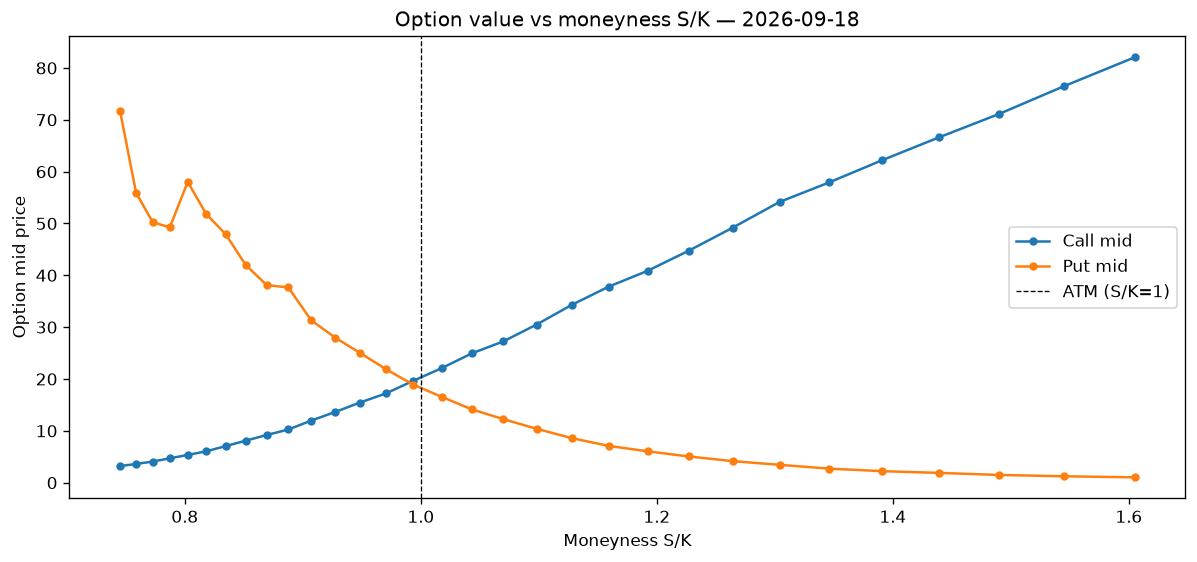

In [7]:
mny = S / parity.index.astype(float)
plt.plot(mny, parity["call"], marker="o", ms=4, label="Call")
plt.plot(mny, parity["put"], marker="o", ms=4, label="Put")
plt.axvline(1.0, color="k", ls="--", lw=0.8, label="ATM")
plt.xlabel("Moneyness S/K")
plt.ylabel("Option mid price")
plt.title(f"Call & put value vs moneyness — {EXPRY}")
plt.legend()
plt.show()


**Answer (2.1):** Calls rise with moneyness (higher as $S/K$ increases / strikes fall); puts do the opposite. The curves are **smooth and convex**, sitting *above* the kinked intrinsic payoff lines — that gap is time value. So it resembles the payoff shape, but it is **not** the sharp final payoff diagram; before expiry both sides stay strictly positive.


### 2.2.

For ATM strike=210, plot call and put values vs expiration (or days to expiration) across the sheets in the file.

What do you notice?


,expiry,days,call,put
0,2026-07-17,39,10.72,11.00
1,2026-08-21,74,15.93,15.65
2,2026-09-18,102,19.64,18.92
3,2026-10-16,130,22.60,21.00
4,2026-11-20,165,26.09,24.03


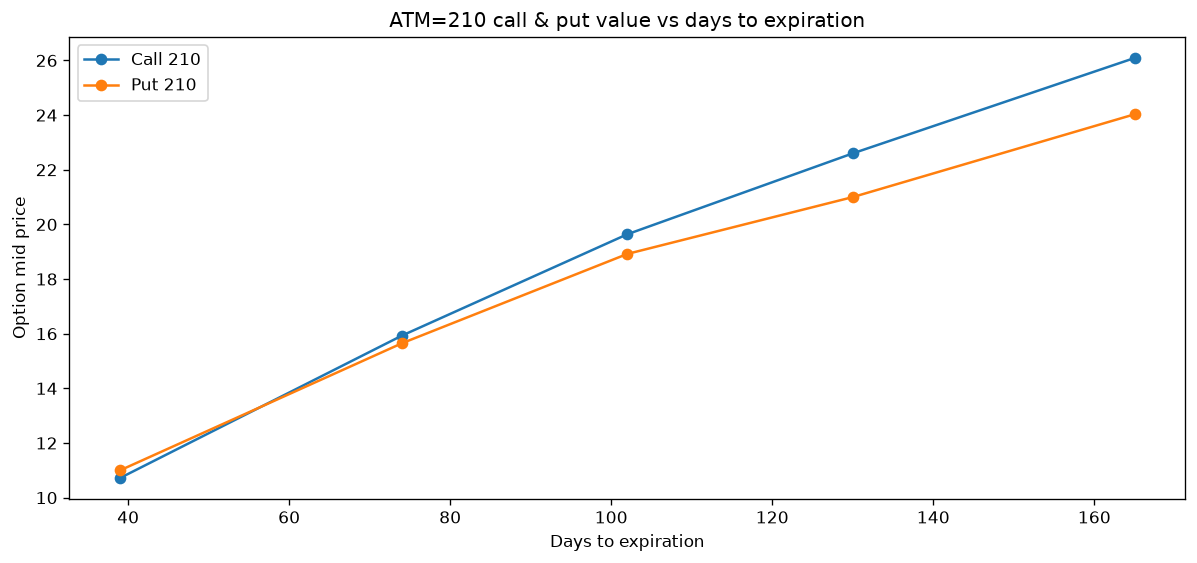

In [8]:
expiries = ["2026-07-17", "2026-08-21", "2026-09-18", "2026-10-16", "2026-11-20"]
rows = []
for sheet in expiries:
    o = pd.read_excel(FILEDATA, sheet_name=sheet)
    c = o[(o["option type"].str.lower() == "call") & (o["strike price"] == ATM)].iloc[0]
    p = o[(o["option type"].str.lower() == "put") & (o["strike price"] == ATM)].iloc[0]
    rows.append({"expiry": sheet, "days": int(c["days to expiration"]), "call": float(c["price"]), "put": float(p["price"])})
multi = pd.DataFrame(rows)
display(multi)

plt.plot(multi["days"], multi["call"], marker="o", label="Call 210")
plt.plot(multi["days"], multi["put"], marker="o", label="Put 210")
plt.xlabel("Days to expiration")
plt.ylabel("Option mid price")
plt.title("ATM=210 values across expirations")
plt.legend()
plt.show()


**Answer (2.2):** Both the ATM call and put **increase with maturity** — more time value as days-to-expiration rise. They stay in a similar ballpark (near-ATM, put≈call after carry), and the gap between them moves a bit with the financing/dividend embed, but the main pattern is simply: **longer-dated options are more expensive**.


***


# 3. Building an Options Position


Use the `2026-09-18` market data.

### 3.1.
For each trade below, calculate the cost of putting it on.

### 3.2.
In a sentence, describe what exposure the position has.

### 3.3.
Plot the payoff of each of the three strategies.

#### Contract size
One option contract = 100 shares.


| Package | Component | Position | Quantity | Strike |
|---------|-----------|----------|----------|--------|
| **A** | Shares | — | 0 | — |
|       | Call | **Long** | 1 | 210 |
|       | Put | **Long** | 1 | 210 |
| **B** | Shares | — | 0 | — |
|       | Call | **Short** | 1 | 245 |
|       | Put | **Long** | 1 | 195 |
| **C** | Shares | **Long** | 100 | — |
|       | Call | **Short** | 1 | 245 |
|       | Put | **Long** | 1 | 195 |


In [9]:
def package_cost(legs):
    cost = 0.0
    lines = []
    for typ, K, q in legs:
        if typ == "stock":
            leg = q * S
            lines.append(f"  long {q} shares @ {S:.2f}: ${leg:,.2f}")
        elif typ == "call":
            px = float(calls.loc[K, "price"])
            leg = q * px * MULT
            side = "long" if q > 0 else "short"
            lines.append(f"  {side} {abs(q)} call {K} @ {px:.2f}: ${leg:,.2f}")
        else:
            px = float(puts.loc[K, "price"])
            leg = q * px * MULT
            side = "long" if q > 0 else "short"
            lines.append(f"  {side} {abs(q)} put {K} @ {px:.2f}: ${leg:,.2f}")
        cost += leg
    return cost, lines

packages = {
    "A": [("call", 210, 1), ("put", 210, 1)],
    "B": [("call", 245, -1), ("put", 195, 1)],
    "C": [("stock", None, 100), ("call", 245, -1), ("put", 195, 1)],
}

costs = {}
for name, legs in packages.items():
    cost, lines = package_cost(legs)
    costs[name] = cost
    print(f"Package {name} cost = ${cost:,.2f}")
    print("\n".join(lines))
    print()


Package A cost = $3,856.00
long 1 call 210: $1,964.00
long 1 put 210: $1,892.00

Package B cost = $415.00
short 1 call 245: $-810.00
long 1 put 195: $1,225.00

Package C cost = $21,279.00
stock x100: $20,864.00
short 1 call 245: $-810.00
long 1 put 195: $1,225.00


**Answers (3.1–3.2):**

- **A — Long straddle (cost $3,856.00):** Long volatility / big move either direction; loses if NVDA expires near 210.
- **B — Risk reversal / wide collar without stock (cost $415.00):** Long downside below 195, short upside above 245; roughly a bearish-to-neutral skew view, limited if spot stays between the strikes.
- **C — Collar on long stock (cost $21,279.00):** Long 100 shares protected by the 195 put and capped by the short 245 call — hedged bullish: participates up to 245, floored below 195.


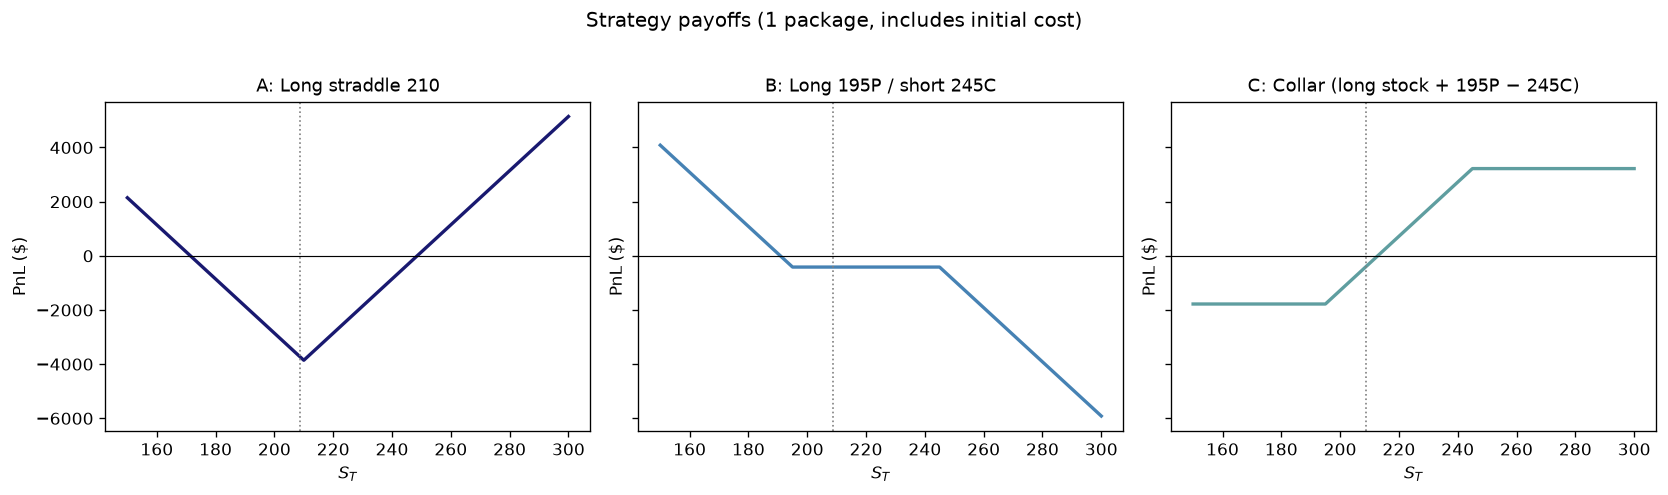

In [10]:
ST = np.linspace(150, 300, 301)
cost_A, cost_B, cost_C = costs["A"], costs["B"], costs["C"]

pay_A = MULT * (np.maximum(ST - 210, 0) + np.maximum(210 - ST, 0)) - cost_A
pay_B = MULT * (-np.maximum(ST - 245, 0) + np.maximum(195 - ST, 0)) - cost_B
pay_C = 100 * ST + MULT * (-np.maximum(ST - 245, 0) + np.maximum(195 - ST, 0)) - cost_C

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, pay, title, col in [
    (axes[0], pay_A, "A: Long straddle 210", "midnightblue"),
    (axes[1], pay_B, "B: Long 195P / short 245C", "steelblue"),
    (axes[2], pay_C, "C: Collar (stock + 195P − 245C)", "cadetblue"),
]:
    ax.plot(ST, pay, color=col, lw=2)
    ax.axhline(0, color="k", lw=0.7)
    ax.axvline(S, color="gray", ls=":", lw=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(r"$S_T$")
    ax.set_ylabel("PnL ($)")
fig.suptitle("Payoffs for one package (includes initial cost)", y=1.03)
plt.tight_layout()
plt.show()


**Answer (3.3):** The plots show (A) the classic V-shaped straddle, (B) a put-spread-like / short-call risk-reversal payoff that pays if the stock falls hard, and (C) the collar’s flat-ish band between the put and call strikes with stock ownership embedded.


***
